# Deuterium Plasma Characterization

This notebook investigates the dependence of fundamental plasma parameters on **plasma density, magnetic field, and temperature** using the PlasmaPy library.

The analysis focuses on a deuterium plasma and calculates characteristic plasma quantities including:

* Alfvén speed
* Ion inertial length
* Debye length
* Electron plasma frequency
* Thermal speed
* Gyrofrequency
* Larmor radius
* Plasma beta

The calculated quantities are compared across different plasma conditions and their physical scaling laws are analyzed using numerical calculations and log-log plots.

### Reference Conditions

* Ion species: D⁺
* Electron species: e⁻
* Density: `10¹⁹ m⁻³`
* Ion temperature: `10 eV`
* Electron temperature: `10 eV`
* Magnetic field: `1 T`


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd

from plasmapy.formulary import (
    Alfven_speed,
    inertial_length,
    Debye_length,
    plasma_frequency,
    gyrofrequency,
    thermal_speed,
    beta,
)

In [2]:
# Reference plasma conditions
n_ref = 1e19 / u.m**3
T_ref = 10 * u.eV
B_ref = 1 * u.T

ion = "D+"
electron = "e-"

# Parameter scans
dens = np.logspace(17, 21, 20) / u.m**3
B_values = np.logspace(-1, 1, 20) * u.T
T_values = np.logspace(0, 3, 20) * u.eV

In [3]:
# Calculate reference plasma parameters

Va_ref = Alfven_speed(B_ref, n_ref, ion)
di_ref = inertial_length(n_ref, ion)
lambdaD_ref = Debye_length(T_ref, n_ref)

omega_pe_ref = plasma_frequency(n_ref, electron)

vth_ion_ref = thermal_speed(T_ref, ion)
vth_electron_ref = thermal_speed(T_ref, electron)

omega_c_ion_ref = gyrofrequency(B_ref, ion)
omega_c_electron_ref = gyrofrequency(B_ref, electron)

rL_ion_ref = vth_ion_ref.value / omega_c_ion_ref.value
rL_electron_ref = vth_electron_ref.value / omega_c_electron_ref.value

beta_ion_ref = beta(T_ref, n_ref, B_ref)
beta_electron_ref = beta(T_ref, n_ref, B_ref)

beta_total_ref = beta_ion_ref + beta_electron_ref

In [4]:
results = {
    "Quantity": [
        "Alfvén speed",
        "Ion inertial length",
        "Debye length",
        "Electron plasma angular frequency",
        "D+ thermal speed",
        "Electron thermal speed",
        "D+ Larmor radius",
        "Electron Larmor radius",
        "Ion beta",
        "Electron beta",
        "Total beta",
    ],
    "Value": [
        Va_ref,
        di_ref,
        lambdaD_ref,
        omega_pe_ref,
        vth_ion_ref,
        vth_electron_ref,
        rL_ion_ref * u.m,
        rL_electron_ref * u.m,
        beta_ion_ref,
        beta_electron_ref,
        beta_total_ref,
    ],
}

results_df = pd.DataFrame(results)
results_df

,Quantity,Value
0,Alfvén speed,4877865.428615532 m / s
1,Ion inertial length,0.10181007917940751 m
2,Debye length,7.433941997219252e-06 m
3,Electron plasma angular frequency,178398636416.04175 rad / s
4,D+ thermal speed,30957.37256053281 m / s
5,Electron thermal speed,1875537.2608284797 m / s
6,D+ Larmor radius,0.0006460496594435721 m
7,Electron Larmor radius,1.0663611125041266e-05 m
8,Ion beta,4.0267090739704405e-05
9,Electron beta,4.0267090739704405e-05


## Density Dependence

The dependence of selected plasma parameters on ion density is investigated for fixed temperature and magnetic field.

- Ion and electron temperature: $10\ \mathrm{eV}$
- Magnetic field: $1\ \mathrm{T}$
- Density range: $10^{17}$–$10^{21}\ \mathrm{m^{-3}}$

In [5]:
# Density scan

alfven_speeds = []
ion_lengths = []
debye_lengths = []

for n in dens:
    Va = Alfven_speed(B_ref, n, ion)
    di = inertial_length(n, ion)
    lambda_D = Debye_length(T_ref, n)

    alfven_speeds.append(Va.value)
    ion_lengths.append(di.value)
    debye_lengths.append(lambda_D.value)

C:\Users\Morte3a\AppData\Local\Programs\Python\Python313\Lib\site-packages\plasmapy\utils\decorators\checks.py:1396: RelativityWarning: Alfven_speed is yielding a velocity that is 16.271% of the speed of light. Relativistic effects may be important.
  warnings.warn(
C:\Users\Morte3a\AppData\Local\Programs\Python\Python313\Lib\site-packages\plasmapy\utils\decorators\checks.py:1396: RelativityWarning: Alfven_speed is yielding a velocity that is 12.769% of the speed of light. Relativistic effects may be important.
  warnings.warn(
C:\Users\Morte3a\AppData\Local\Programs\Python\Python313\Lib\site-packages\plasmapy\utils\decorators\checks.py:1396: RelativityWarning: Alfven_speed is yielding a velocity that is 10.02% of the speed of light. Relativistic effects may be important.
  warnings.warn(
C:\Users\Morte3a\AppData\Local\Programs\Python\Python313\Lib\site-packages\plasmapy\utils\decorators\checks.py:1396: RelativityWarning: Alfven_speed is yielding a velocity that is 7.864% of the speed 

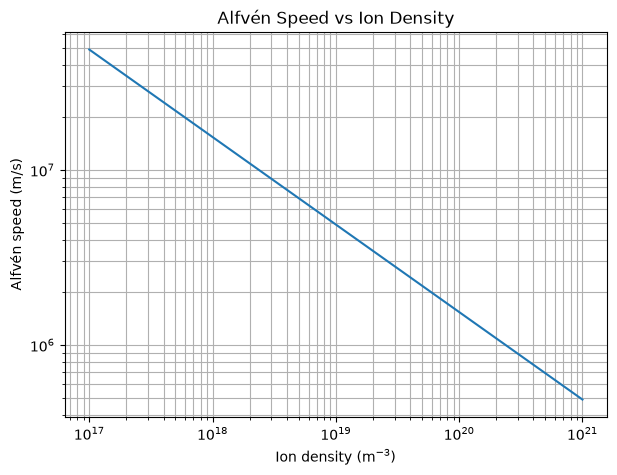

In [6]:
plt.figure(figsize=(7, 5))

plt.loglog(dens.value, alfven_speeds)

plt.xlabel("Ion density (m$^{-3}$)")
plt.ylabel("Alfvén speed (m/s)")
plt.title("Alfvén Speed vs Ion Density")

plt.grid(True, which="both")
plt.show()

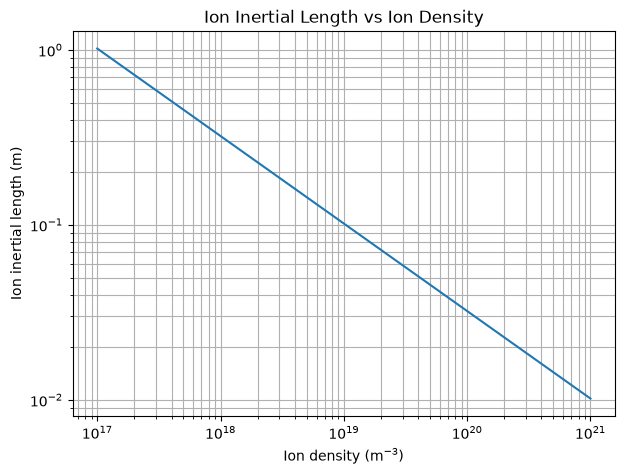

In [7]:
plt.figure(figsize=(7, 5))

plt.loglog(dens.value, ion_lengths)

plt.xlabel("Ion density (m$^{-3}$)")
plt.ylabel("Ion inertial length (m)")
plt.title("Ion Inertial Length vs Ion Density")

plt.grid(True, which="both")
plt.show()

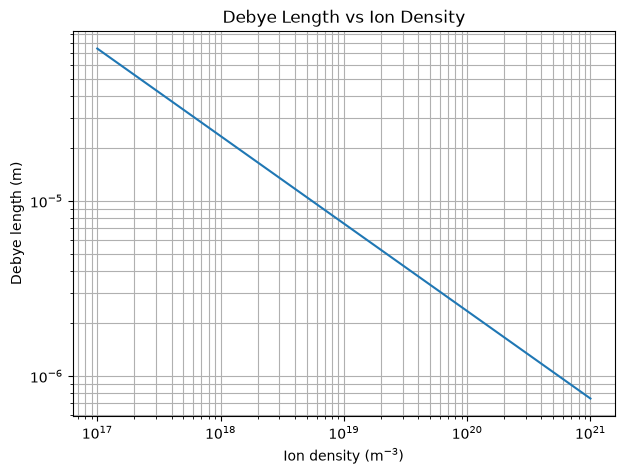

In [8]:
plt.figure(figsize=(7, 5))

plt.loglog(dens.value, debye_lengths)

plt.xlabel("Ion density (m$^{-3}$)")
plt.ylabel("Debye length (m)")
plt.title("Debye Length vs Ion Density")

plt.grid(True, which="both")
plt.show()

In [9]:
# Electron plasma angular frequency vs density

plasma_frequencies = []

for n in dens:
    omega_pe = plasma_frequency(n, electron)
    plasma_frequencies.append(omega_pe.value)

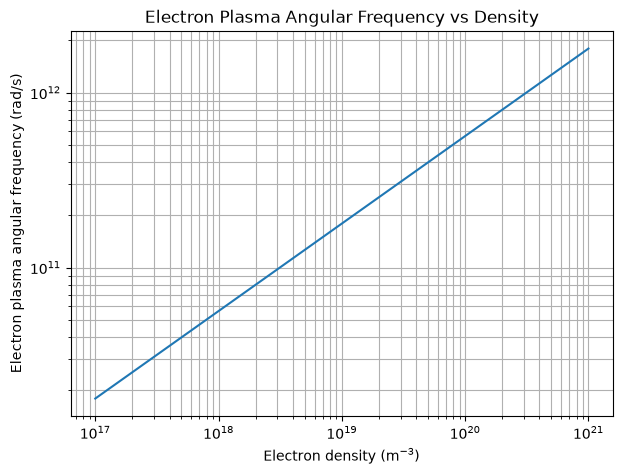

In [10]:
plt.figure(figsize=(7, 5))

plt.loglog(dens.value, plasma_frequencies)

plt.xlabel("Electron density (m$^{-3}$)")
plt.ylabel("Electron plasma angular frequency (rad/s)")
plt.title("Electron Plasma Angular Frequency vs Density")

plt.grid(True, which="both")
plt.show()

## Magnetic Field Dependence

The magnetic-field dependence of selected plasma parameters is investigated for a fixed plasma density and temperature.

- Ion density: $10^{19}\ \mathrm{m^{-3}}$
- Ion and electron temperature: $10\ \mathrm{eV}$
- Magnetic field range: $0.1$–$10\ \mathrm{T}$

In [11]:
# Gyrofrequency vs magnetic field

gyrofrequencies_ion = []
gyrofrequencies_electron = []

for B in B_values:
    omega_ion = gyrofrequency(B, ion)
    omega_electron = gyrofrequency(B, electron)

    gyrofrequencies_ion.append((omega_ion / (2 * np.pi)).value)
    gyrofrequencies_electron.append((omega_electron / (2 * np.pi)).value)

In [12]:
# Display the ion gyrofrequency at the last magnetic-field value
omega_ion / (2 * np.pi)

<Quantity 76263779.35698831 rad / s>

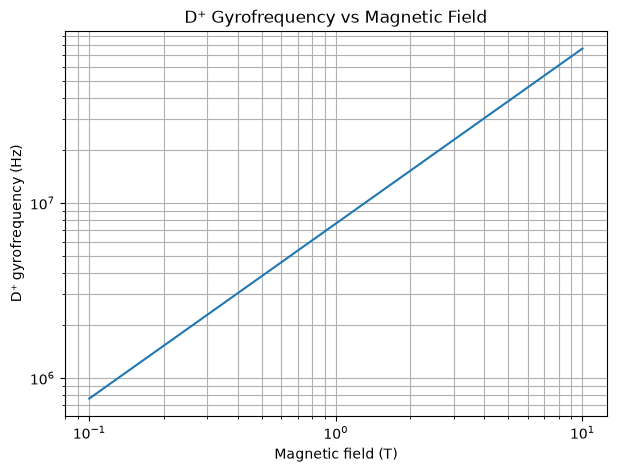

In [13]:
plt.figure(figsize=(7, 5))

plt.loglog(B_values.value, gyrofrequencies_ion)

plt.xlabel("Magnetic field (T)")
plt.ylabel("D⁺ gyrofrequency (Hz)")
plt.title("D⁺ Gyrofrequency vs Magnetic Field")

plt.grid(True, which="both")
plt.show()

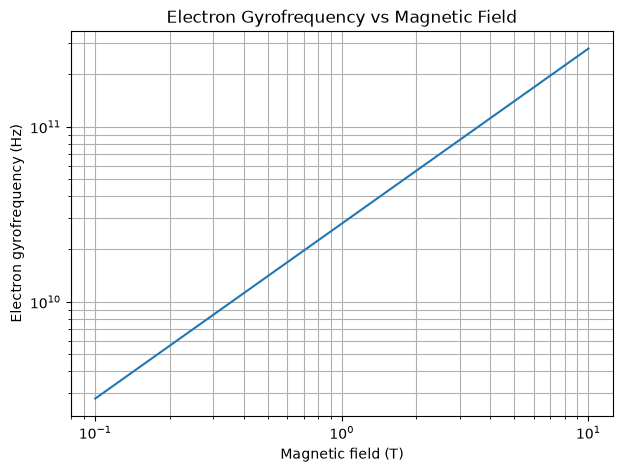

In [14]:
plt.figure(figsize=(7, 5))

plt.loglog(B_values.value, gyrofrequencies_electron)

plt.xlabel("Magnetic field (T)")
plt.ylabel("Electron gyrofrequency (Hz)")
plt.title("Electron Gyrofrequency vs Magnetic Field")

plt.grid(True, which="both")
plt.show()

In [15]:
# Larmor radius vs magnetic field

larmor_radii_ion = []
larmor_radii_electron = []

for B in B_values:
    omega_ion = gyrofrequency(B, ion)
    omega_electron = gyrofrequency(B, electron)

    rL_ion = vth_ion_ref.value / omega_ion.value
    rL_electron = vth_electron_ref.value / omega_electron.value

    larmor_radii_ion.append(rL_ion)
    larmor_radii_electron.append(rL_electron)

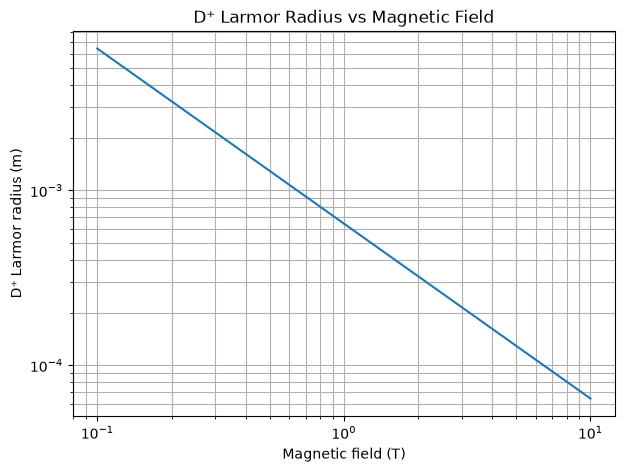

In [16]:
plt.figure(figsize=(7, 5))

plt.loglog(B_values.value, larmor_radii_ion)

plt.xlabel("Magnetic field (T)")
plt.ylabel("D⁺ Larmor radius (m)")
plt.title("D⁺ Larmor Radius vs Magnetic Field")

plt.grid(True, which="both")
plt.show()

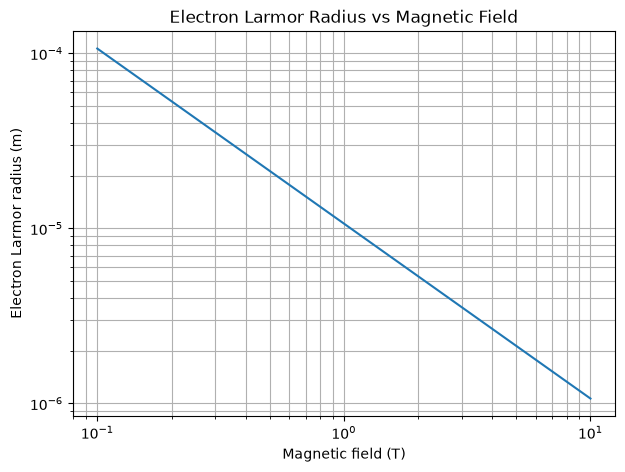

In [17]:
plt.figure(figsize=(7, 5))

plt.loglog(B_values.value, larmor_radii_electron)

plt.xlabel("Magnetic field (T)")
plt.ylabel("Electron Larmor radius (m)")
plt.title("Electron Larmor Radius vs Magnetic Field")

plt.grid(True, which="both")
plt.show()

### Plasma Beta

For the reference plasma, the ion and electron temperatures are assumed to be equal:

$$
T_i = T_e = 10\ \mathrm{eV}
$$

and quasi-neutrality is assumed:

$$
n_i = n_e = 10^{19}\ \mathrm{m^{-3}}
$$

The plasma beta is defined as the ratio of thermal pressure to magnetic pressure. Since both ions and electrons contribute to the total thermal pressure, their contributions are calculated separately and summed:

$$
\beta_{\mathrm{total}} = \beta_i + \beta_e
$$

Because \(T_i=T_e\) and \(n_i=n_e\) in this model, the ion and electron contributions are equal. Therefore,

$$
\beta_i = \beta_e = 4.0267\times10^{-5}
$$

and the total plasma beta is

$$
\beta_{\mathrm{total}} = 8.0534\times10^{-5}.
$$


In [18]:
# Plasma beta vs temperature

beta_temperature = []

for T in T_values:
    beta_T = beta(T, n_ref, B_ref)
    beta_temperature.append(beta_T.value)

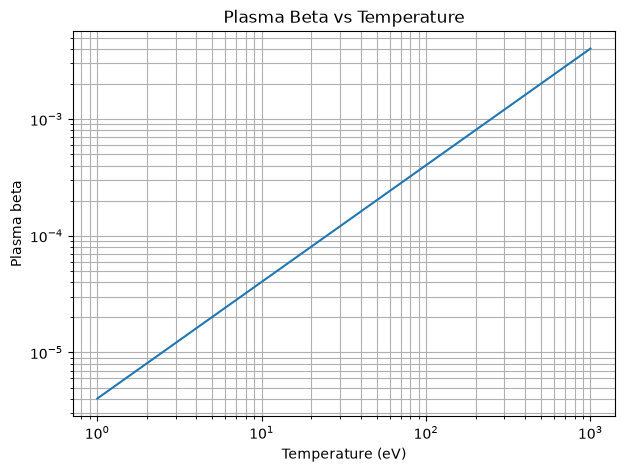

In [19]:
plt.figure(figsize=(7, 5))

plt.loglog(T_values.value, beta_temperature)

plt.xlabel("Temperature (eV)")
plt.ylabel("Plasma beta")
plt.title("Plasma Beta vs Temperature")

plt.grid(True, which="both")
plt.show()

In [20]:
# Plasma beta vs density

beta_density = []

for n in dens:
    beta_n = beta(T_ref, n, B_ref)
    beta_density.append(beta_n.value)

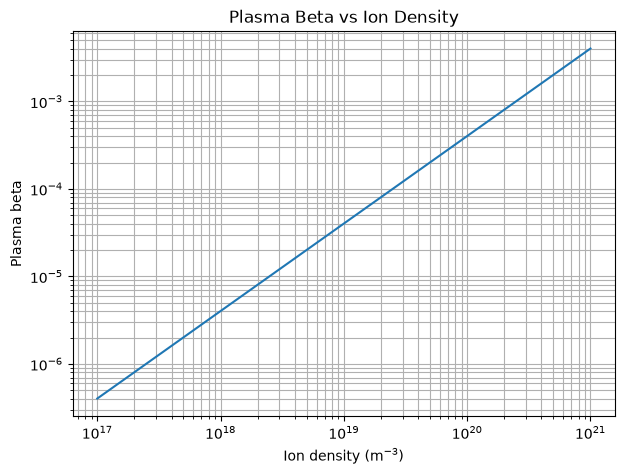

In [21]:
plt.figure(figsize=(7, 5))

plt.loglog(dens.value, beta_density)

plt.xlabel("Ion density (m$^{-3}$)")
plt.ylabel("Plasma beta")
plt.title("Plasma Beta vs Ion Density")

plt.grid(True, which="both")
plt.show()

In [22]:
# Plasma beta vs magnetic field

beta_magnetic_field = []

for B in B_values:
    beta_B = beta(T_ref, n_ref, B)
    beta_magnetic_field.append(beta_B.value)

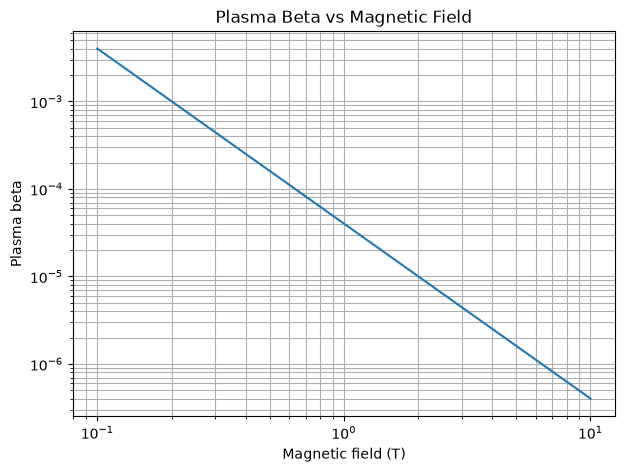

In [23]:
plt.figure(figsize=(7, 5))

plt.loglog(B_values.value, beta_magnetic_field)

plt.xlabel("Magnetic field (T)")
plt.ylabel("Plasma beta")
plt.title("Plasma Beta vs Magnetic Field")

plt.grid(True, which="both")
plt.show()

## Temperature Dependence

The temperature dependence of selected plasma parameters is investigated for a fixed plasma density and magnetic field.

- Ion density: $10^{19}\ \mathrm{m^{-3}}$
- Magnetic field: $1\ \mathrm{T}$
- Temperature range: $1$–$1000\ \mathrm{eV}$

In [24]:
# Larmor radius vs temperature

larmor_radii_ion_temperature = []
larmor_radii_electron_temperature = []

for T in T_values:
    vth_ion = thermal_speed(T, ion)
    vth_electron = thermal_speed(T, electron)

    omega_ion = gyrofrequency(B_ref, ion)
    omega_electron = gyrofrequency(B_ref, electron)

    rL_ion = vth_ion.value / omega_ion.value
    rL_electron = vth_electron.value / omega_electron.value

    larmor_radii_ion_temperature.append(rL_ion)
    larmor_radii_electron_temperature.append(rL_electron)

C:\Users\Morte3a\AppData\Local\Programs\Python\Python313\Lib\site-packages\plasmapy\utils\decorators\checks.py:1396: RelativityWarning: thermal_speed is yielding a velocity that is 5.216% of the speed of light. Relativistic effects may be important.
  warnings.warn(
C:\Users\Morte3a\AppData\Local\Programs\Python\Python313\Lib\site-packages\plasmapy\utils\decorators\checks.py:1396: RelativityWarning: thermal_speed is yielding a velocity that is 6.256% of the speed of light. Relativistic effects may be important.
  warnings.warn(


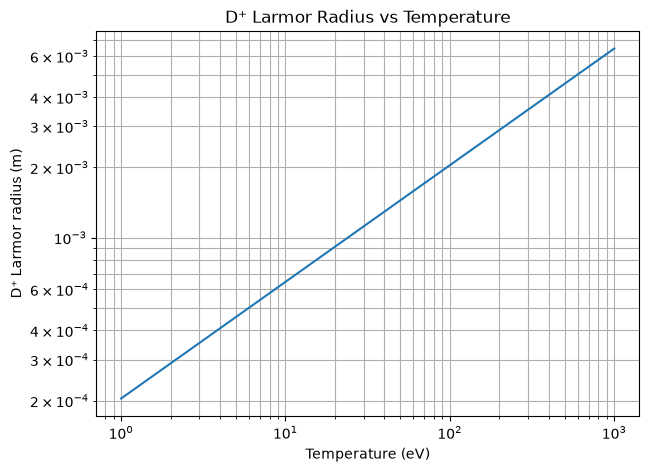

In [25]:
plt.figure(figsize=(7, 5))

plt.loglog(T_values.value, larmor_radii_ion_temperature)

plt.xlabel("Temperature (eV)")
plt.ylabel("D⁺ Larmor radius (m)")
plt.title("D⁺ Larmor Radius vs Temperature")

plt.grid(True, which="both")
plt.show()

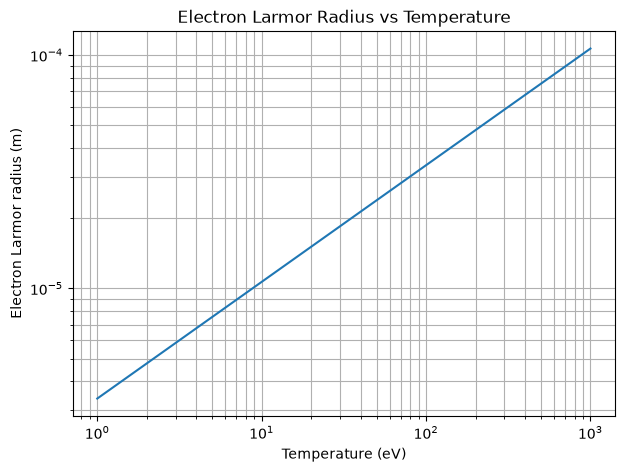

In [26]:
plt.figure(figsize=(7, 5))

plt.loglog(T_values.value, larmor_radii_electron_temperature)

plt.xlabel("Temperature (eV)")
plt.ylabel("Electron Larmor radius (m)")
plt.title("Electron Larmor Radius vs Temperature")

plt.grid(True, which="both")
plt.show()

In [27]:
# Thermal speed vs temperature

thermal_speeds_ion_temperature = []
thermal_speeds_electron_temperature = []

for T in T_values:
    vth_ion = thermal_speed(T, ion)
    vth_electron = thermal_speed(T, electron)

    thermal_speeds_ion_temperature.append(vth_ion.value)
    thermal_speeds_electron_temperature.append(vth_electron.value)

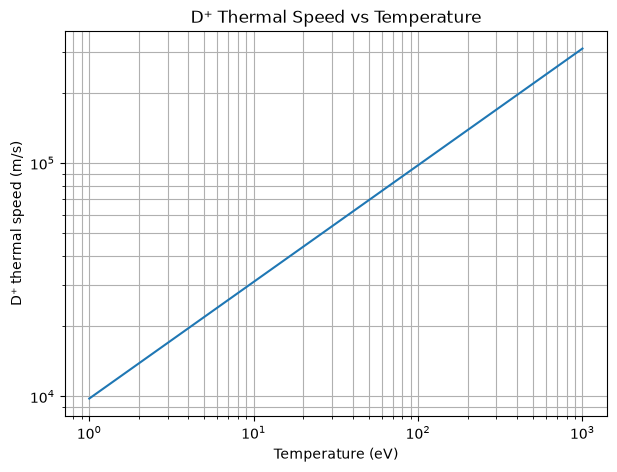

In [28]:
plt.figure(figsize=(7, 5))

plt.loglog(T_values.value, thermal_speeds_ion_temperature)

plt.xlabel("Temperature (eV)")
plt.ylabel("D⁺ thermal speed (m/s)")
plt.title("D⁺ Thermal Speed vs Temperature")

plt.grid(True, which="both")
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.loglog(T_values.value, thermal_speeds_electron_temperature)

plt.xlabel("Temperature (eV)")
plt.ylabel("Electron thermal speed (m/s)")
plt.title("Electron Thermal Speed vs Temperature")

plt.grid(True, which="both")
plt.show()